In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
def pretty_print_matrix(M, decimals=2):
    """Imprime la matriz M con formato bonito."""
    df = pd.DataFrame(M.round(decimals))
    print(df.to_string(index=False, header=False))

In [3]:
# ─────────────────────────────────────────
#  Define tu matriz M aquí
# ─────────────────────────────────────────
rng = np.random.default_rng(seed=42)
M = np.zeros((3,10))
M[0,::] = 1
M[:,5::] *= -1
M += rng.normal(0,0.1,(3,10))
M = M.round(2)


In [4]:

# ─────────────────────────────────────────
#  Calcular SVD
#  full_matrices=False → versión "compacta" (recomendada)
#  full_matrices=True  → versión completa con matrices cuadradas
# ─────────────────────────────────────────
U, sigma, Vt = np.linalg.svd(M, full_matrices=False)

# numpy devuelve sigma como vector 1D con los valores singulares
# si quieres la matriz Σ diagonal completa:
Sigma = np.diag(sigma)


In [5]:
pretty_print_matrix(M)
pretty_print_matrix(U)
pretty_print_matrix(Sigma)
pretty_print_matrix(Vt)

 1.03  0.90 1.08  1.09  0.80 -1.13 -0.99 -1.03 -1.00 -1.09
 0.09  0.08 0.01  0.11  0.05 -0.09  0.04 -0.10  0.09 -0.00
-0.02 -0.07 0.12 -0.02 -0.04 -0.04  0.05  0.04  0.04  0.04
-1.00  0.04  0.01
-0.04 -1.00 -0.02
 0.01 -0.02  1.00
3.22 0.0 0.00
0.00 0.2 0.00
0.00 0.0 0.17
-0.32 -0.28 -0.33 -0.34 -0.25  0.35  0.31 0.32  0.31  0.34
-0.24 -0.21  0.15 -0.33 -0.09  0.23 -0.40 0.29 -0.65 -0.22
-0.04 -0.35  0.80 -0.04 -0.18 -0.32  0.21 0.16  0.14  0.15


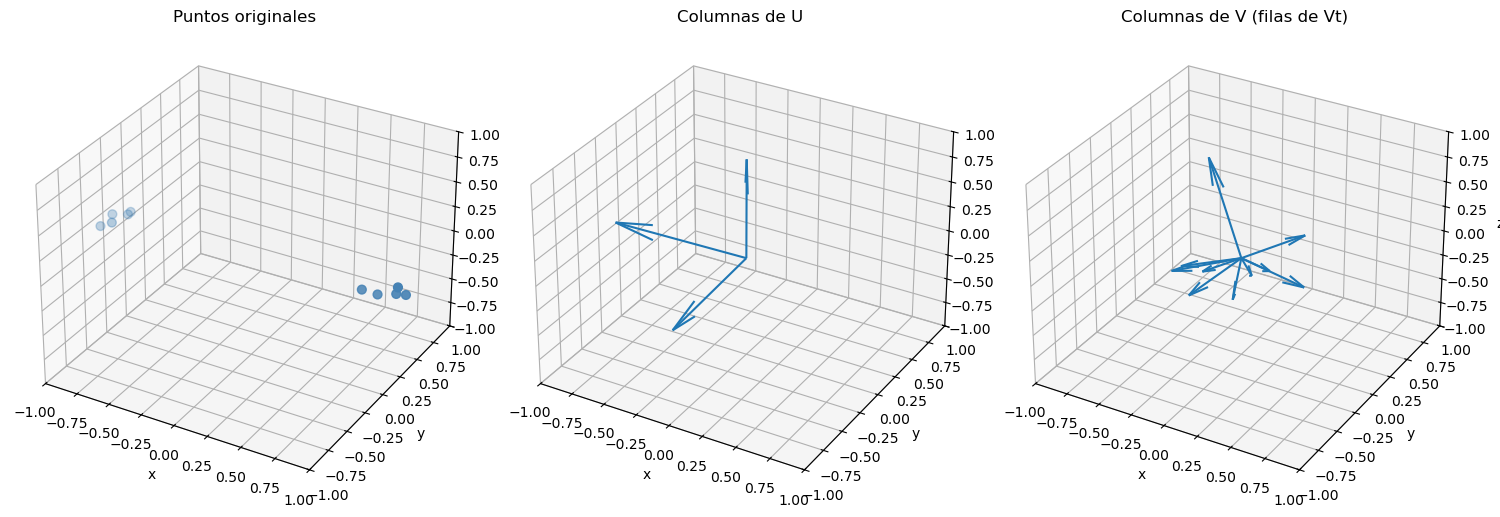

In [6]:

fig = plt.figure(figsize=(15, 5))
origen = np.zeros(3)

# ── Gráfica 1: puntos originales ──
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(M[0], M[1], M[2], c='steelblue', s=40)
ax1.set_title('Puntos originales')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_xlim([-1,1]); ax1.set_ylim([-1,1]); ax1.set_zlim([-1,1])

# ── Gráfica 2: columnas de U (3 vectores en R³) ──
ax2 = fig.add_subplot(132, projection='3d')
for i in range(U.shape[1]):
    ax2.quiver(*origen, *U[:, i], length=1, normalize=False)
ax2.set_title('Columnas de U')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.set_xlim([-1,1]); ax2.set_ylim([-1,1]); ax2.set_zlim([-1,1])

# ── Gráfica 3: columnas de Vt.T = filas de Vt (10 vectores en R³) ──
# Vt es 3×10 → cada columna es un vector en R³
ax3 = fig.add_subplot(133, projection='3d')
for i in range(Vt.shape[1]):
    ax3.quiver(*origen, *Vt[:, i], length=1, normalize=False)
ax3.set_title('Columnas de V (filas de Vt)')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')
ax3.set_xlim([-1,1]); ax3.set_ylim([-1,1]); ax3.set_zlim([-1,1])

plt.tight_layout()
plt.savefig('svd_3d.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:

# ─────────────────────────────────────────
#  Mostrar resultados
# ─────────────────────────────────────────
np.set_printoptions(precision=4, suppress=True)

print("=" * 50)
print(f"Matriz M original  ({M.shape[0]}×{M.shape[1]}):")
print(M)

print(f"\nU  ({U.shape[0]}×{U.shape[1]})  — patrones de salida / columnas:")
print(U)

print(f"\nΣ  ({Sigma.shape[0]}×{Sigma.shape[1]})  — valores singulares (importancia):")
print(Sigma)

print(f"\nVᵀ ({Vt.shape[0]}×{Vt.shape[1]})  — patrones de entrada / filas:")
print(Vt)

print("\nValores singulares ordenados de mayor a menor:")
for i, s in enumerate(sigma):
    pct = (s**2 / np.sum(sigma**2)) * 100
    bar = "█" * int(pct / 2)
    print(f"  σ{i+1} = {s:8.4f}   ({pct:5.1f}% de la energía)  {bar}")

# ─────────────────────────────────────────
#  Verificación: reconstruir M desde U·Σ·Vᵀ
# ─────────────────────────────────────────
M_reconstruida = U @ Sigma @ Vt
error = np.max(np.abs(M - M_reconstruida))
print(f"\nVerificación — error máximo de reconstrucción: {error:.2e}")
print("(debería ser prácticamente 0)\n")

# ─────────────────────────────────────────
#  Aproximación de rango k
#  Quedarse solo con los k primeros componentes
# ─────────────────────────────────────────
def aproximar_rango_k(U, sigma, Vt, k):
    """Reconstruye M usando solo los k valores singulares más grandes."""
    return U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :]

print("=" * 50)
print("Aproximaciones de rango k:\n")
for k in range(1, len(sigma) + 1):
    M_k = aproximar_rango_k(U, sigma, Vt, k)
    energia = (np.sum(sigma[:k]**2) / np.sum(sigma**2)) * 100
    error_k = np.linalg.norm(M - M_k, 'fro')  # error de Frobenius
    print(f"  k={k}  →  energía capturada: {energia:5.1f}%   error Frobenius: {error_k:.4f}")
    if k == len(sigma):
        print(f"\n  Reconstrucción exacta con k={k}:")
        print(f"  {np.round(M_k, 4)}")


Matriz M original  (3×10):
[[ 1.03  0.9   1.08  1.09  0.8  -1.13 -0.99 -1.03 -1.   -1.09]
 [ 0.09  0.08  0.01  0.11  0.05 -0.09  0.04 -0.1   0.09 -0.  ]
 [-0.02 -0.07  0.12 -0.02 -0.04 -0.04  0.05  0.04  0.04  0.04]]

U  (3×3)  — patrones de salida / columnas:
[[-0.9991  0.0394  0.014 ]
 [-0.0397 -0.999  -0.0196]
 [ 0.0132 -0.0201  0.9997]]

Σ  (3×3)  — valores singulares (importancia):
[[3.2233 0.     0.    ]
 [0.     0.2017 0.    ]
 [0.     0.     0.1697]]

Vᵀ (3×10)  — patrones de entrada / filas:
[[-0.3205 -0.2802 -0.3344 -0.3393 -0.2488  0.3512  0.3066  0.3207  0.309
   0.338 ]
 [-0.2424 -0.2133  0.1496 -0.3297 -0.0873  0.2288 -0.3966  0.2899 -0.6452
  -0.217 ]
 [-0.0432 -0.3474  0.7951 -0.0405 -0.1754 -0.3186  0.2083  0.1622  0.1427
   0.1457]]

Valores singulares ordenados de mayor a menor:
  σ1 =   3.2233   ( 99.3% de la energía)  █████████████████████████████████████████████████
  σ2 =   0.2017   (  0.4% de la energía)  
  σ3 =   0.1697   (  0.3% de la energía)  

Verificación